In [ ]:
#USO DE DOCUMENTACION  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
##uso de documentacion pytorch https://docs.pytorch.org/docs/stable/generated/torch.quantile.html#torch-quantile
#Uso de IA de la pagina de pytorch para encontrar funciones y apis.

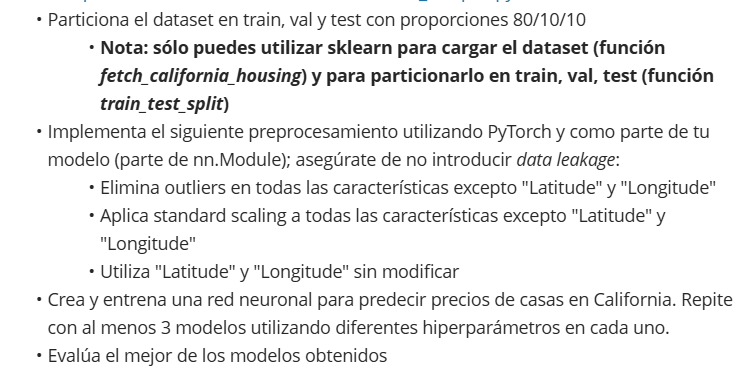

In [12]:
from sklearn.datasets import fetch_california_housing

x, y = fetch_california_housing(return_X_y=True, as_frame=True)

x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Particiona el dataset en train, val y test con proporciones 80/10/10
Nota: sólo puedes utilizar sklearn para cargar el dataset (función fetch_california_housing) y para particionarlo en train, val, test (función train_test_split)


In [17]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.20, random_state=42
) #2.0 siendo el 20 %, random state 42 por ser el default de la documentacion

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42
) #50% de 20 es 10, se logra el requisito de 80/10/10


Remove outliers:



In [18]:
#pasos de preprocesamiento para train
import torch
import torch.nn as nn

#tensor x train
x_traint = torch.tensor(x_train.values, dtype=torch.float32)#crear tensor de la presentacion 6. Pytorch

# indices de columnas que NO se modifican (Latitude, Longitude)
latid = 6
longit = 7

mask = torch.ones(x_traint.shape[1], dtype=torch.bool) #documentacion pytorch

#eliminar los que no se modificaran
mask[latid] = False
mask[longit] = False

#Guardar todos excepto los que estan en false
x_features = x_traint[:, mask]

#guardar los que sean false
x_latlon = x_traint[:, ~mask] #los agregaremos de vuelta luego

#elimina outlisers en todos las categorias excepto en latitud y longitude, usando IQR ya que se puede usar torch.quantile

Q1 = torch.quantile(x_features, 0.25, dim=0) #eonctrar el valor donde 25% de los datos en x son iguales o menores
Q3 = torch.quantile(x_features, 0.75, dim=0) #encontrar el valor donde 75% de los datos son igual o menores
IQR = Q3 - Q1 # interquartile range, el rango de los datos cercanos a la mediana

#limites inferiores y superiores para que no se consideren outliers, 1.5 por ser parte de la formula
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#poner solo los datos dentro de nuestro rango usando clamp
x_features = torch.clamp(x_features, lower, upper)

Standard scaling:


https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [19]:
#aplicar standard scaling en todos menos latitud y longitud

#formula dado por scikit learn z = (x - promedio)/desvuacion estandar

promedio = torch.mean(x_features, dim=0)
desviacion = torch.std(x_features, dim=0)

x_features = (x_features - promedio) / desviacion #standard scaling

#reconstruir para regresar latitud y longitud
x_procesados = torch.cat((x_features, x_latlon), dim=1) #utiliza latitud y longitud sin modificar

val y test

In [20]:
#preprocesamiento para val y test

class PreprocessingLayer(nn.Module):#presentacion 8
    def forward(self, x): #preprocesamiento para validacion y test
      x_feat = x[:, mask] #Guardar todos excepto los que estan en false
      x_latlon = x[:, ~mask] #AGREGAR LUEGO LAT Y LON

      x_feat = torch.clamp(x_feat, lower, upper)
      x_feat = (x_feat - promedio) / desviacion #mismo calculo

      return torch.cat([x_feat, x_latlon], dim=1)

In [24]:
#volver tensor
x_val_t = torch.tensor(x_val.values, dtype=torch.float32)
x_test_t = torch.tensor(x_test.values, dtype=torch.float32)

pre = PreprocessingLayer()#usar clase

x_val_processed = pre.forward(x_val_t)#procesar
x_test_processed = pre.forward(x_test_t)#procesar

In [25]:
from torch.utils.data import TensorDataset, DataLoader #basado en la actividad 4 para separar los datos

#convertir en tensores
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

X_val_t = torch.tensor(x_val_processed, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32)

X_test_t = torch.tensor(x_test_processed, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)


#usar funciones importadas para data
train_data = TensorDataset(x_traint, y_train_t)
val_data   = TensorDataset(X_val_t, y_val_t)
test_data  = TensorDataset(X_test_t, y_test_t)

batch_size = 64

#usar funciones para loader
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

/tmp/ipykernel_473/4105255080.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val_t = torch.tensor(x_val_processed, dtype=torch.float32)
/tmp/ipykernel_473/4105255080.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_t = torch.tensor(x_test_processed, dtype=torch.float32)


crea y entrana 3 modelos

train

In [26]:
#funcion train de la actividad 4
from tqdm import tqdm

def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    """
    Train the model and record training and validation losses for each epoch.
    Note that the input model will be mutated.
    For each epoch, loss is averaged across
    :return: Two lists: training_losses and validation_losses.
    """
    training_losses = [] #listas para regresar
    validation_losses = [] #listas para regresar

    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0

        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch + 1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        training_losses.append(epoch_train_loss) # Agrega la pérdida de entrenamiento a la lista
        validation_losses.append(epoch_val_loss) # Agrega la pérdida de validación a la lista
        print(f"epoch {epoch+1} loss: {epoch_train_loss:.2f} (train) | {epoch_val_loss:.2f} (val)")


    return training_losses, validation_losses # Devuelve listas

datasets

In [28]:
#modelo 1, uno simple
model1 = nn.Sequential(
    nn.Linear(8, 64), #capa oculta 64
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)#.001 optmizer

trainingloss1, validationloss1 = train(model1, train_loader, val_loader, criterion, optimizer, 50)

Epoch 1/50:   0%|          | 0/258 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1/50: 100%|██████████| 258/258 [00:00<00:00, 439.18it/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch 1 loss: 116.31 (train) | 8.12 (val)


Epoch 2/50: 100%|██████████| 258/258 [00:00<00:00, 413.12it/s]


epoch 2 loss: 2.15 (train) | 8.67 (val)


Epoch 3/50: 100%|██████████| 258/258 [00:00<00:00, 426.87it/s]


...

epoch 48 loss: 1.67 (train) | 1.33 (val)


Epoch 49/50: 100%|██████████| 258/258 [00:00<00:00, 565.89it/s]


epoch 49 loss: 3.18 (train) | 1.57 (val)


Epoch 50/50: 100%|██████████| 258/258 [00:00<00:00, 383.72it/s]


epoch 50 loss: 1.57 (train) | 1.62 (val)


In [30]:
#model 2 mas profundo

model2 = nn.Sequential(
    nn.Linear(8, 128),
    nn.ReLU(),
    nn.Linear(128, 64),#ocultas de 128 y  64
    nn.ReLU(),
    nn.Linear(64, 1)
)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0005)#.0005 de optmnizer

trainingloss2, validationloss2 = train(model2, train_loader, val_loader, criterion, optimizer2, 50)

Epoch 1/50:   0%|          | 0/258 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1/50: 100%|██████████| 258/258 [00:00<00:00, 479.18it/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch 1 loss: 4.43 (train) | 1.38 (val)


Epoch 2/50: 100%|██████████| 258/258 [00:00<00:00, 461.61it/s]


epoch 2 loss: 6.29 (train) | 1.45 (val)


Epoch 3/50: 100%|██████████| 258/258 [00:00<00:00, 475.39it/s]


...

epoch 48 loss: 1.42 (train) | 1.36 (val)


Epoch 49/50: 100%|██████████| 258/258 [00:00<00:00, 371.67it/s]


epoch 49 loss: 1.37 (train) | 1.34 (val)


Epoch 50/50: 100%|██████████| 258/258 [00:00<00:00, 347.14it/s]

epoch 50 loss: 1.40 (train) | 1.33 (val)


In [33]:
#model 3
model3 = nn.Sequential(
    nn.Linear(8, 256), #mucho mas profundo de 64,128,256
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.0001)#.0001 optmizer

trainingloss3, validationloss3 = train(model3, train_loader, val_loader, criterion, optimizer3, 50)

Epoch 1/50:   0%|          | 0/258 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1/50: 100%|██████████| 258/258 [00:01<00:00, 251.89it/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch 1 loss: 31.04 (train) | 1.49 (val)


Epoch 2/50: 100%|██████████| 258/258 [00:01<00:00, 232.68it/s]


epoch 2 loss: 1.40 (train) | 1.39 (val)


Epoch 3/50: 100%|██████████| 258/258 [00:01<00:00, 204.18it/s]


...

epoch 48 loss: 1.46 (train) | 1.32 (val)


Epoch 49/50: 100%|██████████| 258/258 [00:00<00:00, 280.81it/s]


epoch 49 loss: 1.40 (train) | 1.32 (val)


Epoch 50/50: 100%|██████████| 258/258 [00:00<00:00, 277.76it/s]


epoch 50 loss: 1.39 (train) | 1.33 (val)


evalua el mejor de los tres

In [31]:
import matplotlib.pyplot as plt#funcion de actividad 3

def plot_learning_curves(train_losses, val_losses, title="Learning Curves"):

    epochs = range(1, len(train_losses) + 1)

    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

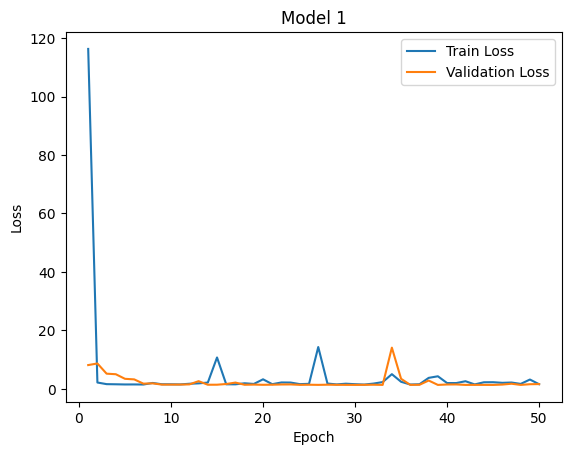

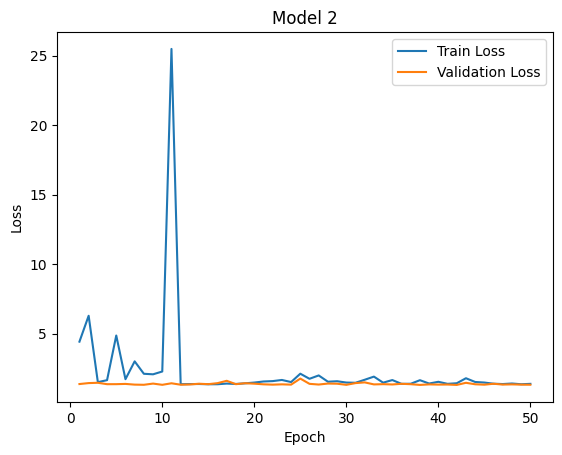

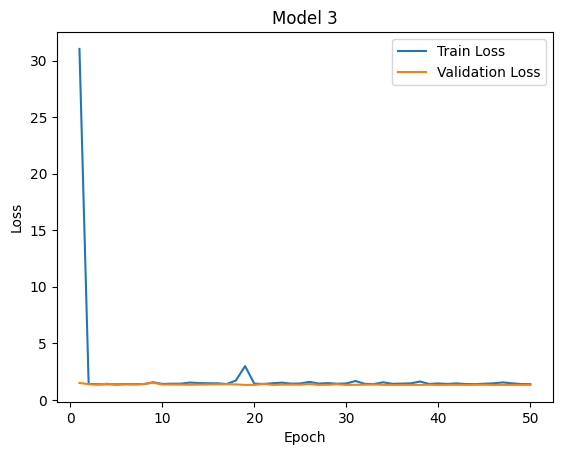

In [34]:
plot_learning_curves(trainingloss1, validationloss1, "Model 1")
plot_learning_curves(trainingloss2, validationloss2, "Model 2")
plot_learning_curves(trainingloss3, validationloss3, "Model 3")

In [35]:
#extension de actividad 3

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X, y in loader:
            outputs = model(X).squeeze()
            loss = nn.MSELoss()(outputs, y)
            total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)

m1 = evaluate(model1, val_loader)
m2 = evaluate(model2, val_loader)
m3 = evaluate(model3, val_loader)

print("Model 1:", m1)
print("Model 2:", m2)
print("Model 3:", m3)

Model 1: 1.6451588212981705
Model 2: 1.3265191307363584
Model 3: 1.3281068912772245


In [37]:
#escoger el mejor

best_model = min(m1, m2, m3)

print("El mejor modelo es el 2 con:", best_model)

El mejor modelo es el 2 con: 1.3265191307363584


Conclusion breve:

* El balance de no irse tan profundo con las capas ocultas de 64 y 128 y un optimizer de .0005 resultó tener el menor MSE mean square error. Me sorprende, debido a que comunmente conecto con los mas detallados y directos siendo los mas eficientes, pero aquí demuestra que no era necesario irse tan profundo, aunque la diferencia sea no tan notable de aproximadamente .002.